# OULAD: подготовка и разведочный анализ

Ноутбук дублирует логику `scripts/analyze_oulad.py` через публичный API проекта.

Итог выполнения:
* CSV-сводки и таблицы - `data/processed/oulad/tables/`
* графики (`.png`) - `data/processed/oulad/figures/`
* готовый `DatasetBundle` с mixed-step каталогом (через `build_oulad_bundle`).

Перед запуском убедитесь, что OULAD распакован в `data/raw/oulad`
(`python scripts/download_data.py --dataset oulad`).

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import api
from src.data.preprocess_oulad import OULADAnalyzerPreprocessor
from src.data.oulad_reports import run_full_analysis

config = api.build_config("oulad", yaml_path=str(ROOT / "configs" / "oulad.yaml"))
print({k: v for k, v in config.get("dataset", {}).items() if not k.startswith("_")})

{'type': 'oulad', 'raw_dir': 'data/raw/oulad', 'processed_dir': 'data/processed/oulad', 'kaggle_name': 'anlgrbz/student-demographics-online-education-dataoulad', 'catalog': {'mode': 'mixed', 'top_activity_types': 6, 'top_assessment_types': 3, 'bucket_delay': True}, 'min_weeks': 2, 'train_ratio': 0.8, 'val_ratio': 0.1, 'test_ratio': 0.1, 'random_seed': 42, 'proxy_weights': {'outcome_mastery': 0.7, 'outcome_final_result': 0.3, 'engagement_clicks': 0.35, 'engagement_active_days': 0.25, 'engagement_resource_breadth': 0.2, 'engagement_activity_breadth': 0.1, 'engagement_regularity': 0.1, 'selfreg_ontime': 0.4, 'selfreg_delay': 0.25, 'selfreg_submission': 0.2, 'selfreg_continuity': 0.15}, 'force_rebuild': False}


## 1. Разведочный анализ

Генерируем таблицы (сводка, распределение `final_result`, корреляции прокси-критериев) и графики (динамика VLE, структура assessment, heatmap корреляций и т.п.).

In [2]:
ds_cfg = config.get("dataset", {})
raw_dir = ROOT / ds_cfg.get("raw_dir", "data/raw/oulad")
analysis_dir = ROOT / ds_cfg.get("analysis_dir", "data/processed/oulad")

analyzer = OULADAnalyzerPreprocessor(data_dir=str(raw_dir), output_dir=str(analysis_dir))
summary = run_full_analysis(analyzer)
summary

{'n_student_presentations': 32593,
 'n_unique_students': 28785,
 'n_unique_modules': 7,
 'n_presentations': 22,
 'n_assessment_rows_after_merge': 242670,
 'n_vle_rows_after_merge': 10625840,
 'mean_available_weeks': 28.56002822691989,
 'median_available_weeks': 35.0,
 'mean_mastery': 0.267922917562209,
 'mean_engagement': 0.20584231678396397,
 'mean_selfregulation': 0.6785000304904233,
 'mean_outcome': 0.3291193862631103}

oulad_assessment_structure.png


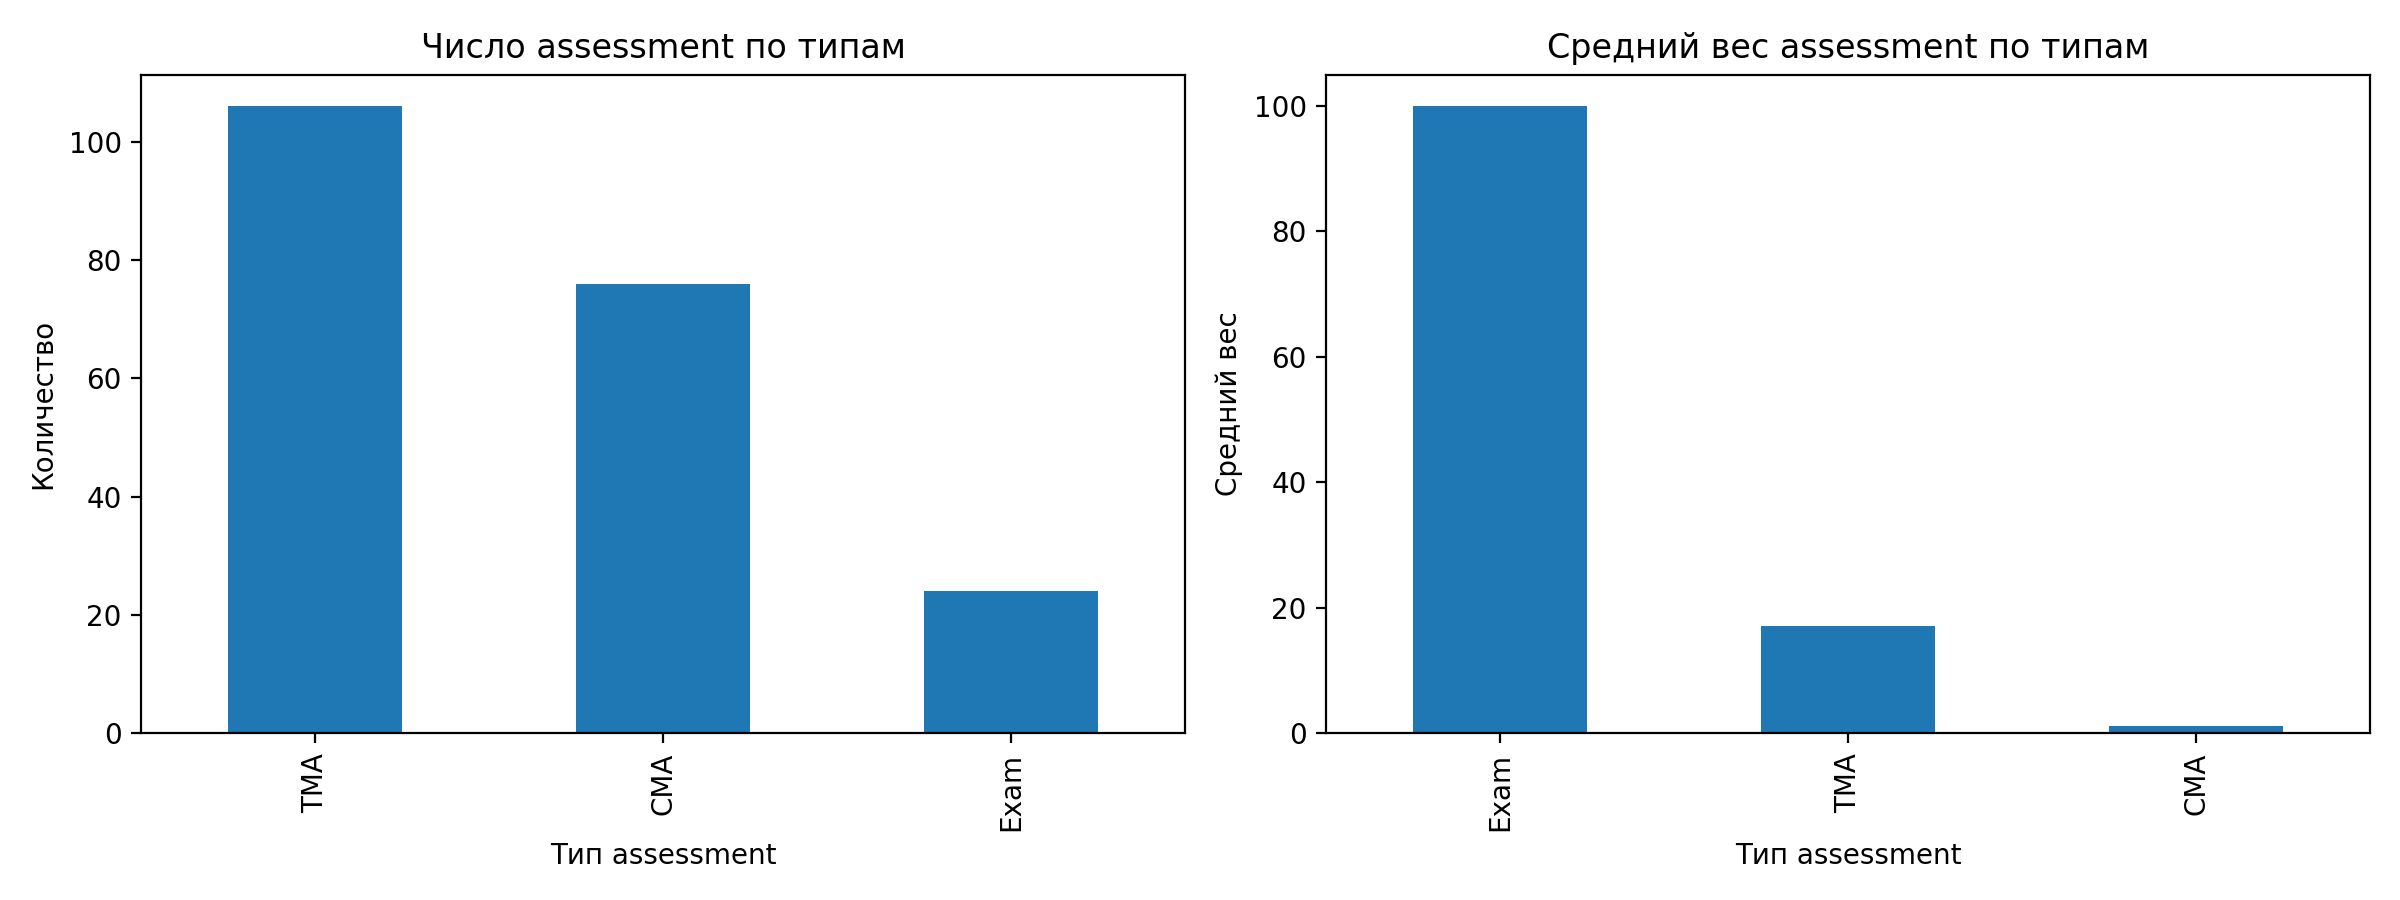

oulad_context_module_impacts.png


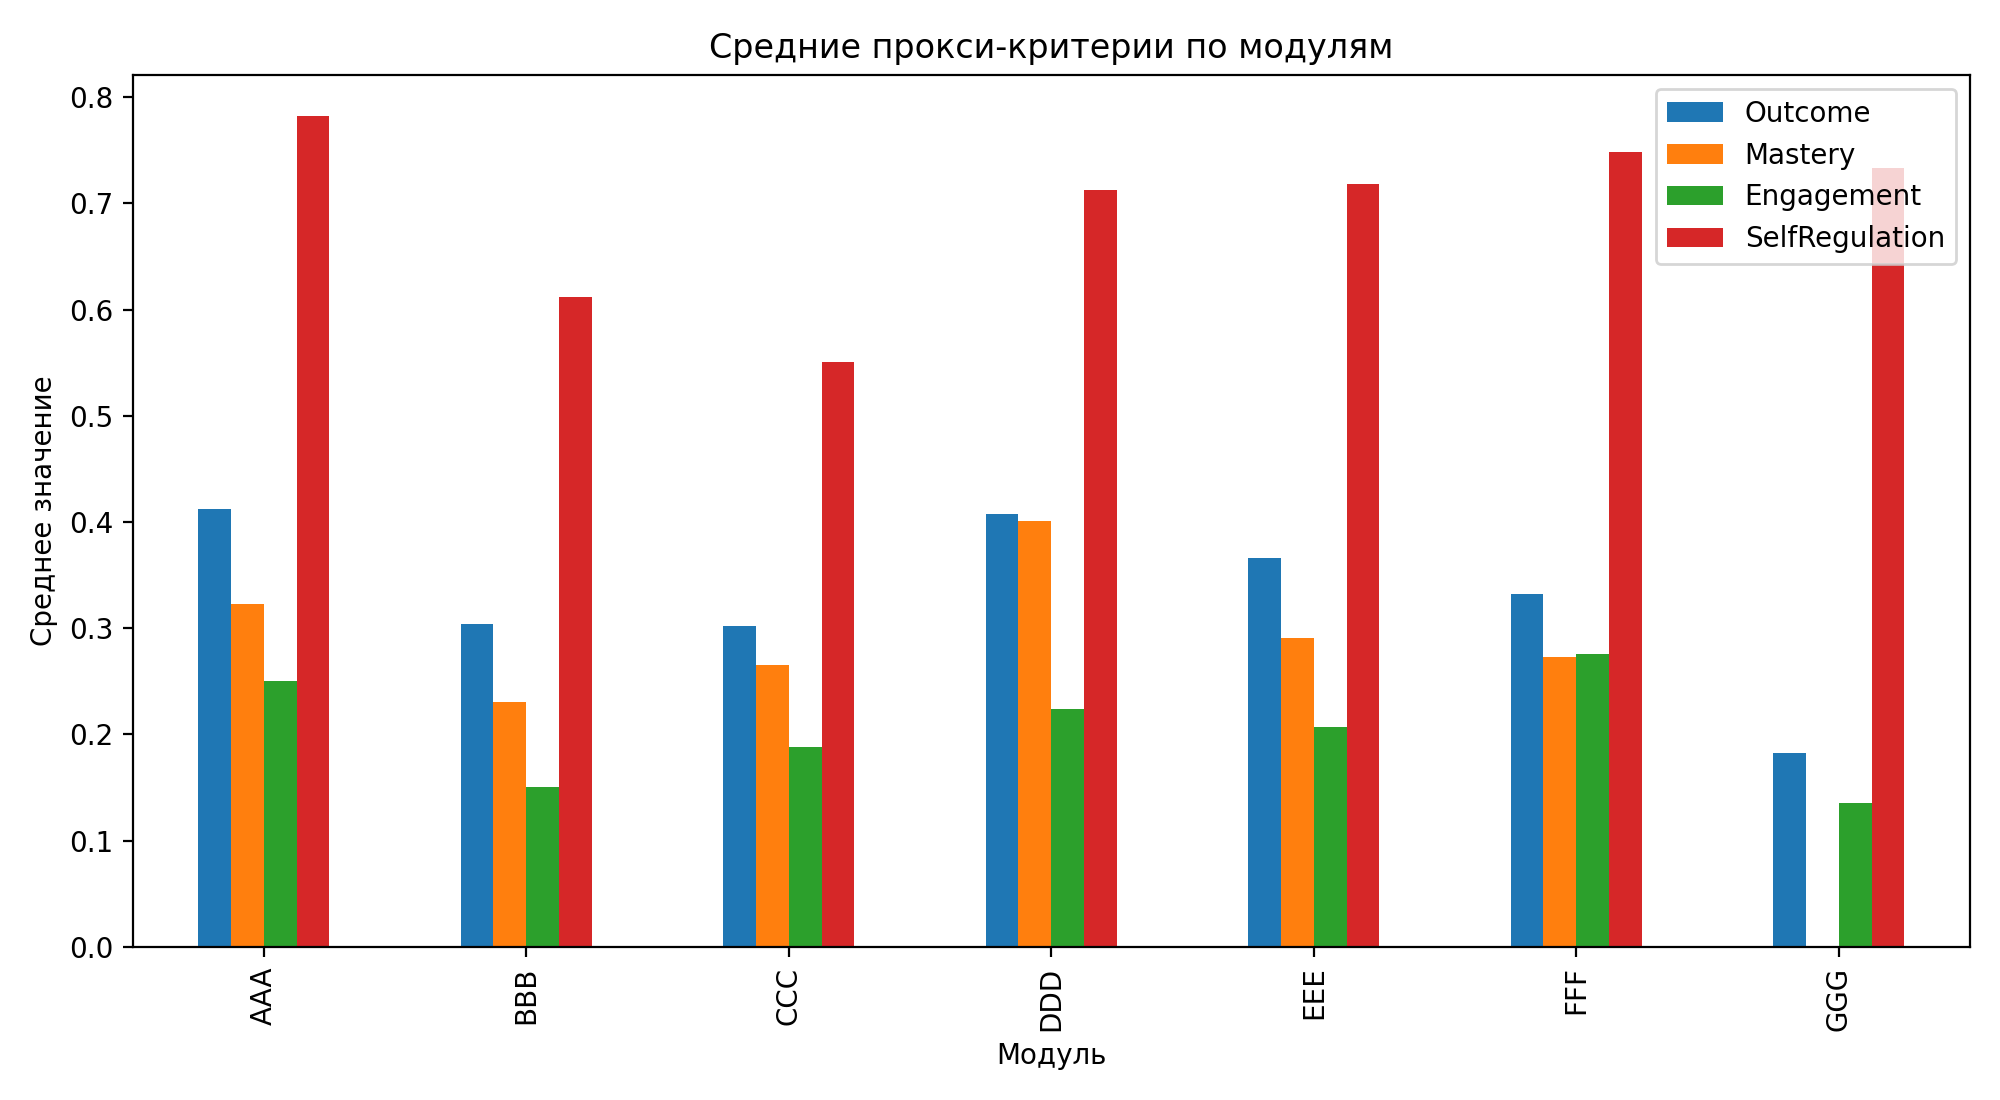

oulad_final_result_distribution.png


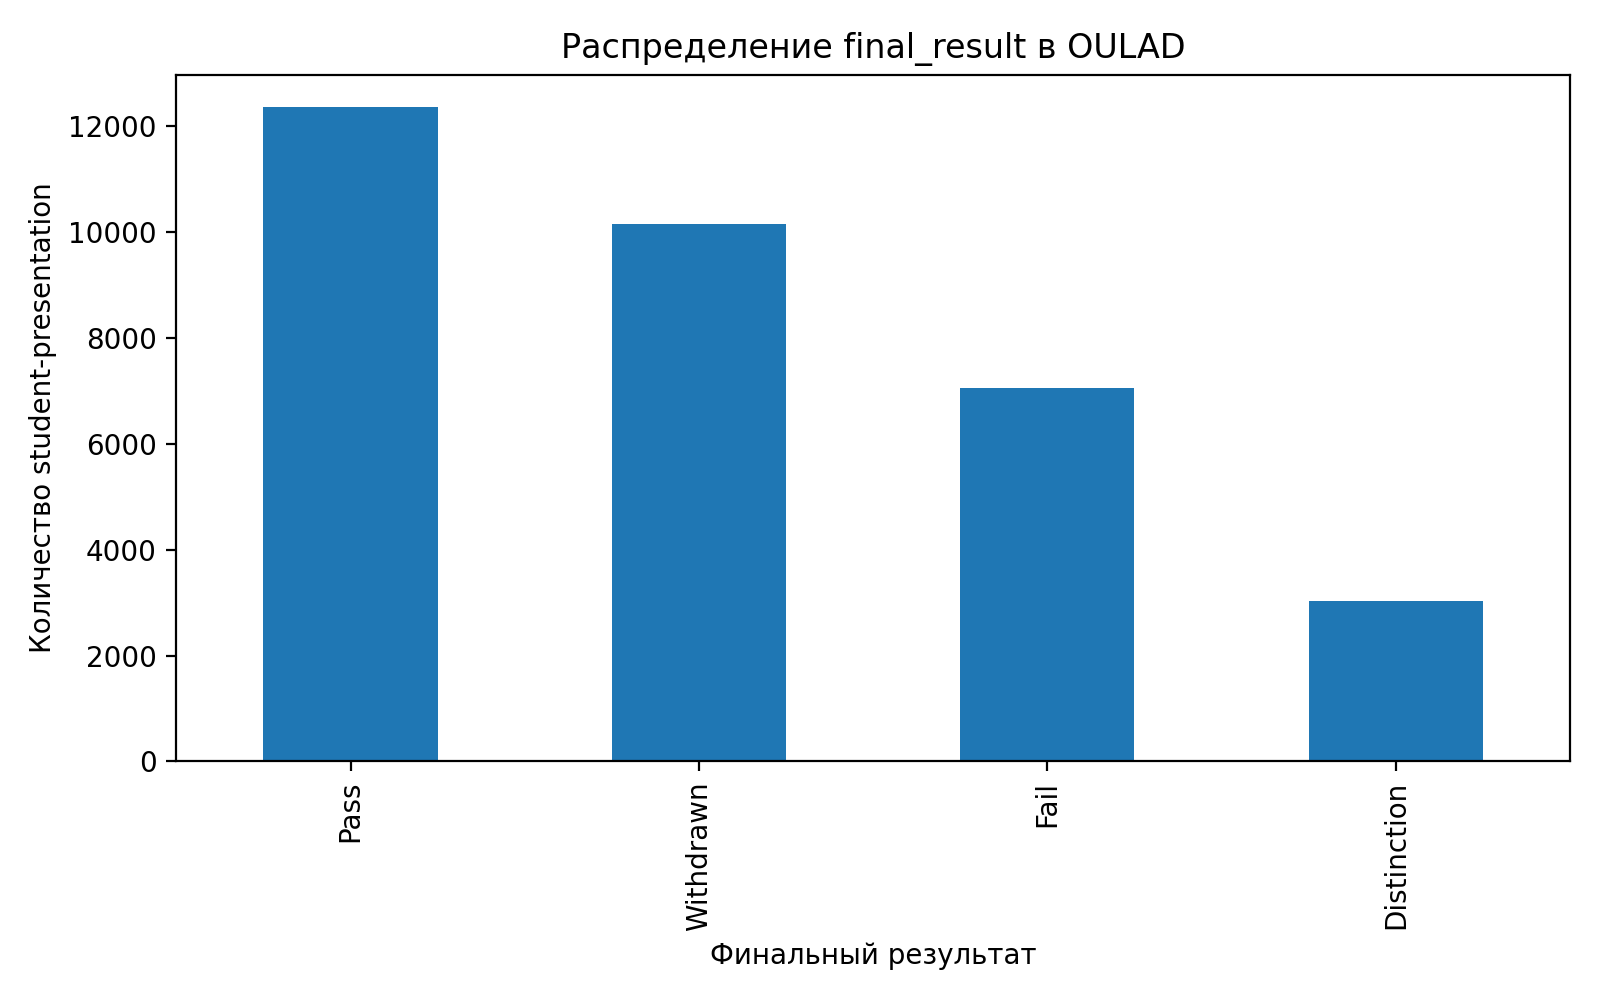

oulad_proxy_correlation_heatmap.png


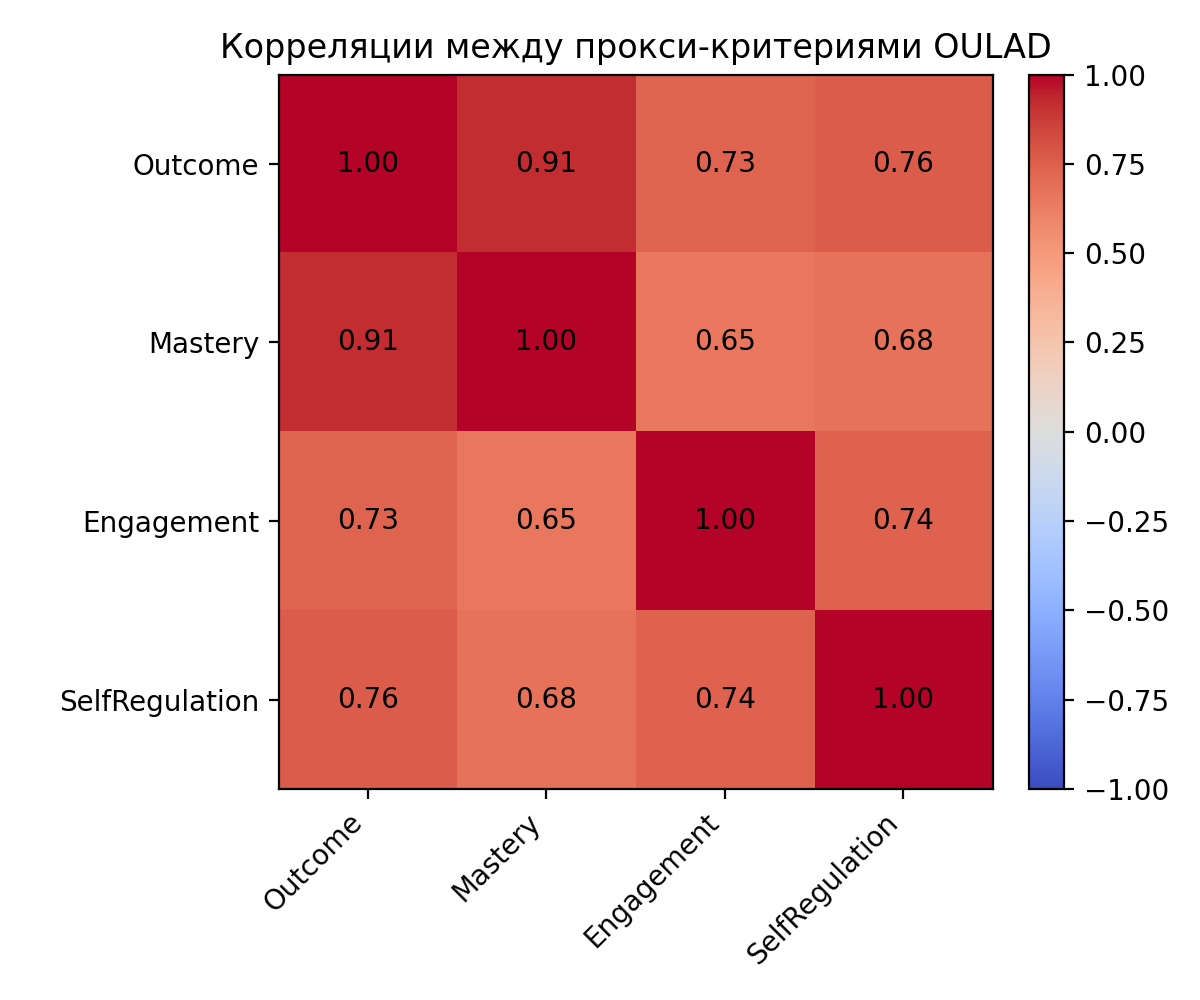

oulad_submission_delay_distribution.png


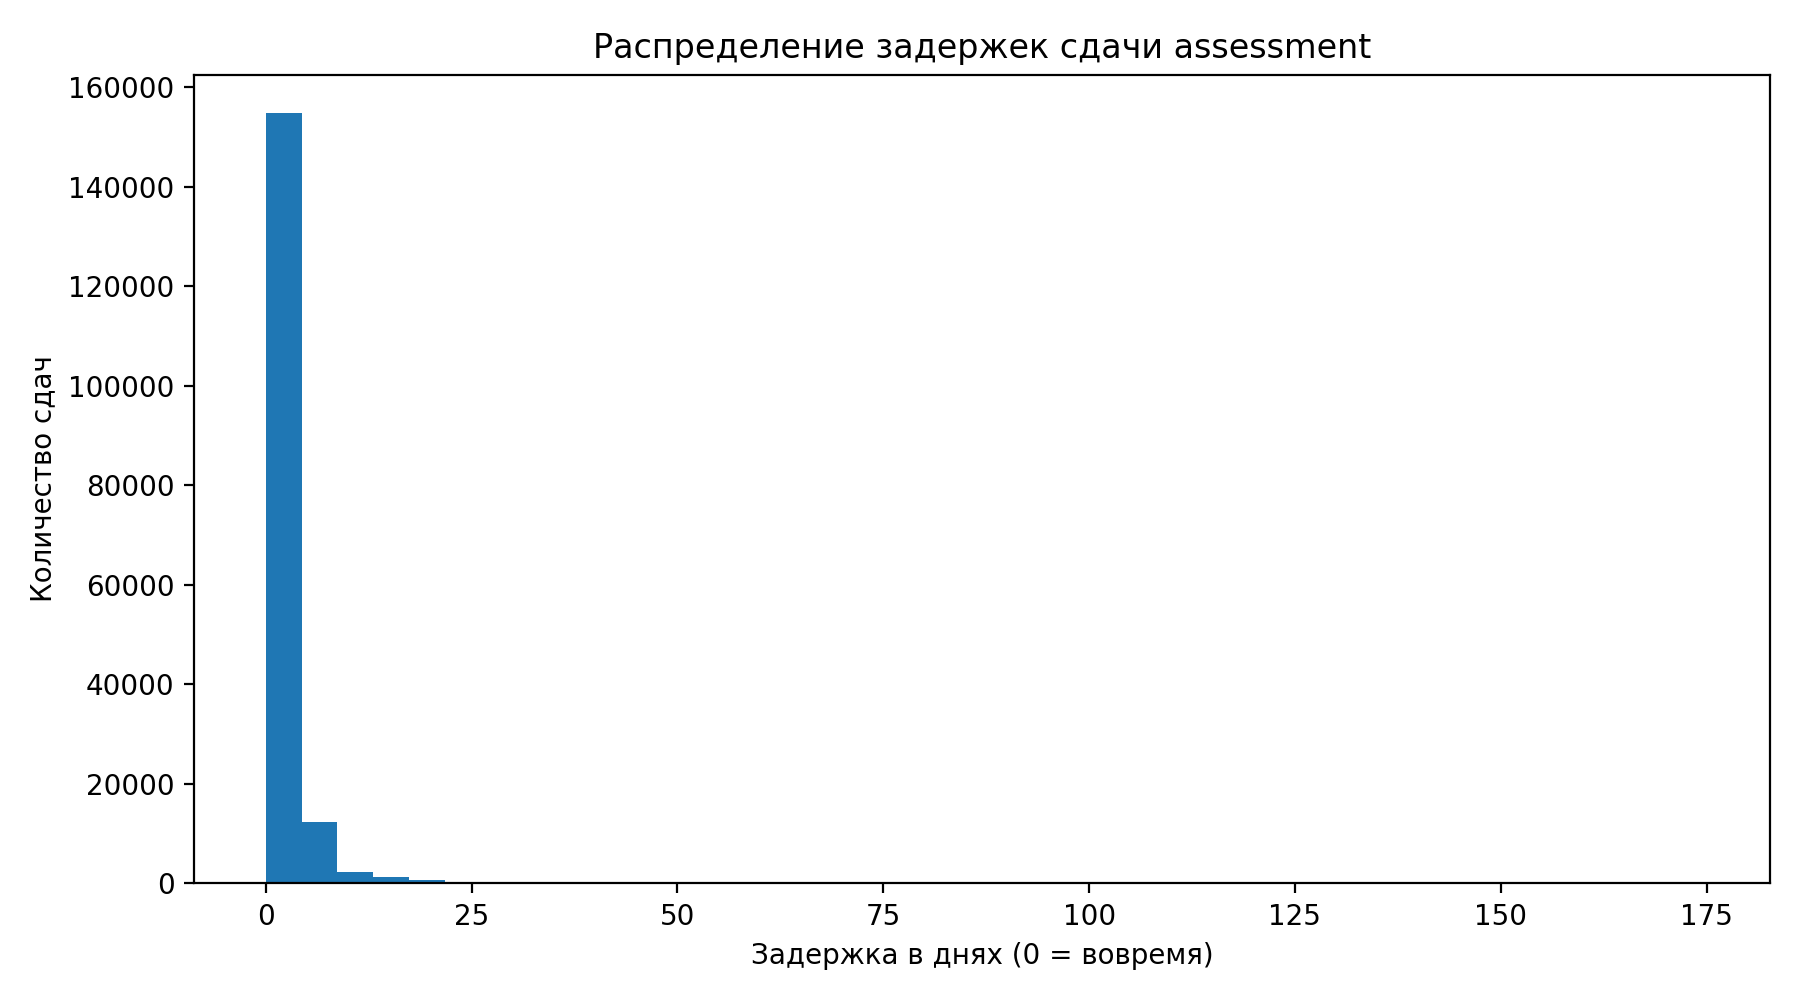

oulad_weekly_vle_dynamics.png


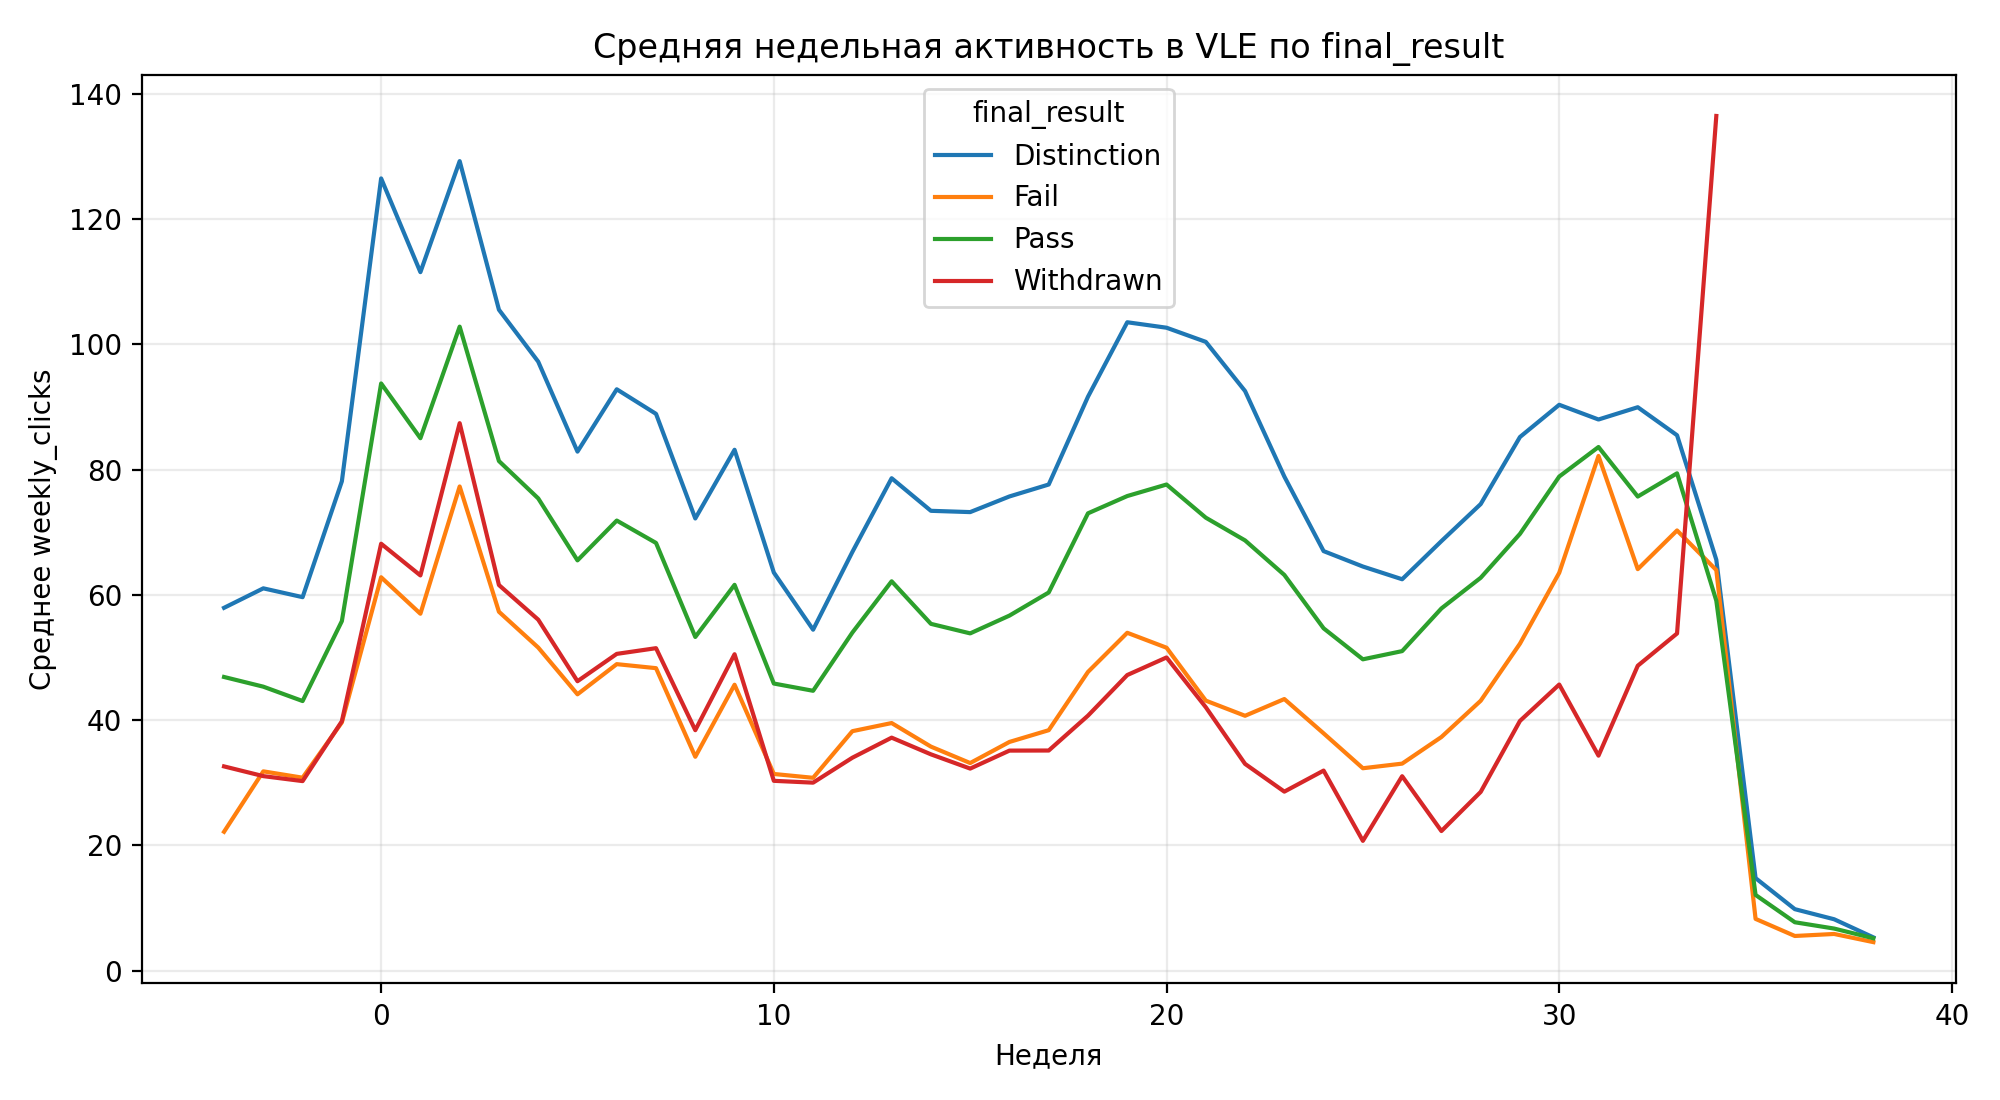

In [3]:
from IPython.display import Image, display

for png in sorted(Path(analyzer.fig_dir).glob("*.png")):
    print(png.name)
    display(Image(filename=str(png)))

## 2. `DatasetBundle` и mixed-step каталог

Блок запускает полноценный `build_oulad_bundle`, формирует:
* `bundle.ratings` - step-level таблица (`student_presentation_id × mixed_step_id`, прокси-критерии);
* `bundle.items` - каталог mixed-step элементов с признаками (`kind`, `activity_type`, `assessment_type`, `bucket_delay`, `week_from`, `week_to`);
* `bundle.users` - демография + final_result;
* `bundle.metadata["trajectories"]` - weekly-траектории VLE.

In [4]:
bundle = api.load_dataset_bundle("oulad", config=config)
for key, value in bundle.describe().items():
    print(f"{key:>30s}: {value}")

                  dataset_type: oulad
                       n_users: 29632
                       n_items: 18
                     state_dim: 96
                n_ratings_rows: 2318825
                target_columns: ['Mastery', 'Engagement', 'SelfRegulation', 'Outcome']
               context_columns: ['Module_encoded', 'Presentation_encoded']
                 context_sizes: [7, 4]
              has_trajectories: False
              has_action_masks: False
                 metadata_keys: ['raw_dir', 'processed_dir', 'catalog_mode', 'catalog', 'items_meta', 'student_features', 'weekly', 'assessments_expected', 'vle_daily_summary', 'final_result_map']


In [ ]:
import pandas as pd

print("Размер ratings:", bundle.ratings.shape)
print("Размер items:", bundle.items.shape)
display(bundle.items.head(10))
display(bundle.ratings[["User_encoded", "Item_encoded", "Mastery", "Engagement", "Outcome"]].head())